You can upload files from your local system to the Colab environment using `files.upload()`:

In [ ]:
#part 1.1
from google.colab import files
import pandas as pd
import numpy as np
uploaded = files.upload()
df=pd.read_csv('Housing.csv')

#print rows
print("First 5 rows:")
print(df.head())

#dataset shape
print("\nDataset Shape:", df.shape)

#basic statistics
print("\nBasic Statistics:")
print(df.describe())

Saving Housing.csv to Housing.csv
First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape: (545, 13)

Basic Statistics:
      

In [ ]:
#part 1.2
#handling missin values
# Check for null values
print("\nNull values in each column:")
print(df.isnull().sum())

# check how much row percent data missing
# threshold = total columns 70% (mean 30% se zyada missing na ho)
threshold_limit = int(0.7 * df.shape[1])

# only keepng those rows which have 70% data, drop those having less than 30%
df = df.dropna(thresh=threshold_limit)

#altho data has no missing value still im filling with mean for assignment formality
# fill remaining null rows with mean
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

print("Missing values after processing:")
print(df.isnull().sum())


Null values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Missing values after processing:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
#feature scaling
#Z-score Standardization

#furnishing status values change so model can interpret
#giving values: unfurnished:0, semi-furnished:1,furnished:2
df['furnishingstatus']=df['furnishingstatus'].map({'unfurnished':0,'semi-furnished':1,'furnished':2})

# Yes/No features list
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
# convert all at once in 0,1: 1 for yes, 0 for no
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# column area
df['area'] = (df['area'] - df['area'].mean()) / df['area'].std()
# column bedrooms
df['bedrooms'] = (df['bedrooms'] - df['bedrooms'].mean()) / df['bedrooms'].std()
# column bathrooms
df['bathrooms'] = (df['bathrooms'] - df['bathrooms'].mean()) / df['bathrooms'].std()
# column stories
df['stories'] = (df['stories'] - df['stories'].mean()) / df['stories'].std()
# column mainroad
df['mainroad'] = (df['mainroad'] - df['mainroad'].mean()) / df['mainroad'].std()
# column guestroom
df['guestroom'] = (df['guestroom'] - df['guestroom'].mean()) / df['guestroom'].std()
# column basement
df['basement'] = (df['basement'] - df['basement'].mean()) / df['basement'].std()
# column hotwaterheating
df['hotwaterheating'] = (df['hotwaterheating'] - df['hotwaterheating'].mean()) / df['hotwaterheating'].std()
# column airconditioning
df['airconditioning'] = (df['airconditioning'] - df['airconditioning'].mean()) / df['airconditioning'].std()
# column parking
df['parking'] = (df['parking'] - df['parking'].mean()) / df['parking'].std()
# column prefarea
df['prefarea'] = (df['prefarea'] - df['prefarea'].mean()) / df['prefarea'].std()
# column furnishingstatus
df['furnishingstatus'] = (df['furnishingstatus'] - df['furnishingstatus'].mean()) / df['furnishingstatus'].std()
# column price
df['price'] = (df['price'] - df['price'].mean()) / df['price'].std()

# printing 5 rows to make sure the Z-score scaling worked
print(df[['area', 'bedrooms','bathrooms','furnishingstatus','stories','parking','mainroad','guestroom','basement','hotwaterheating','airconditioning','price']].head())

       area  bedrooms  bathrooms  furnishingstatus   stories   parking  \
0  1.045766  1.402131   1.420507          1.404995  1.376952  1.516299   
1  1.755397  1.402131   5.400847          1.404995  2.529700  2.676950   
2  2.216196  0.047235   1.420507          0.091578  0.224204  1.516299   
3  1.082630  1.402131   1.420507          1.404995  0.224204  2.676950   
4  1.045766  1.402131  -0.569663          1.404995  0.224204  1.516299   

   mainroad  guestroom  basement  hotwaterheating  airconditioning     price  
0  0.405251  -0.464888 -0.733865        -0.219063         1.471267  4.562174  
1  0.405251  -0.464888 -0.733865        -0.219063         1.471267  4.000809  
2  0.405251  -0.464888  1.360148        -0.219063        -0.678439  4.000809  
3  0.405251  -0.464888  1.360148        -0.219063         1.471267  3.982096  
4  0.405251   2.147110  1.360148        -0.219063         1.471267  3.551716  


In [ ]:
#Features X, Target y
X = df.drop('price', axis=1).values
y = df['price'].values.reshape(-1, 1)

#Random Shuffling
m = len(y)
indices = np.arange(m)
np.random.seed(42)
np.random.shuffle(indices)

X_shuffled = X[indices]
y_shuffled = y[indices]

# 80% examples as training
train_size = int(0.8 * m)

#split using Manual Indexing
X_train = X_shuffled[:train_size]
X_test = X_shuffled[train_size:]
y_train = y_shuffled[:train_size]
y_test = y_shuffled[train_size:]

#Reporting number of samples
print("--- Train/Test Split Report ---")
print(f"Total number of samples: {m}")
print(f"Number of training samples (80%): {X_train.shape[0]}")
print(f"Number of testing samples (20%): {X_test.shape[0]}")

--- Train/Test Split Report ---
Total number of samples: 545
Number of training samples (80%): 436
Number of testing samples (20%): 109


In [ ]:
#part2
#2.1
#column of ones as the first column of X for intercept
X_train_b = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test_b = np.hstack((np.ones((X_test.shape[0], 1)), X_test))


In [ ]:
#part 2.2
#hypothesis function
def hypothesis(X, theta):
    # h = X * theta
    return np.dot(X, theta)

In [ ]:
#part 2.3
#cost function
def computeMseCost(X, y, theta):
    m = len(y)
    h = hypothesis(X, theta)
    # Mean Squared Error formula: (1/2m) * sum((h-y)^2)
    cost = (1/(2 * m)) * np.sum(np.square(h - y))
    return cost

In [ ]:
#part 2.4
#this function will compute gradient descent on training set using alpha 0.01 and iterations 1000 which will be passed in parameters
def gradientDescentLinear(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []#to save cost of each iteration

    for i in range(iterations):
        h = hypothesis(X, theta)
        # Gradient update rule
        gradient = (1/m) * np.dot(X.T, (h - y))
        theta = theta - alpha * gradient

        # Training cost record
        cost = computeMseCost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history


#theta initialize (size:13,1)
initialTheta = np.zeros((X_train_b.shape[1], 1))

#Parameters set
alpha = 0.01
iterations = 1000

#Model train
finalThetaLinear, JHistoryLinear = gradientDescentLinear(X_train_b, y_train, initialTheta, alpha, iterations)

#Report result
print("Final Theta Values:\n", finalThetaLinear)
print(f"\nMinimized Training Cost: {JHistoryLinear[-1]}")

#Price prediction on test data
y_pred_test = hypothesis(X_test_b, finalThetaLinear)

# Test MSE compute karein
test_mse = computeMseCost(X_test_b, y_test, finalThetaLinear)
print(f"Test MSE: {test_mse}")

Final Theta Values:
 [[-0.01608565]
 [ 0.2829277 ]
 [ 0.05779139]
 [ 0.26074311]
 [ 0.21757509]
 [ 0.08489733]
 [ 0.05176106]
 [ 0.07043093]
 [ 0.09003815]
 [ 0.23709904]
 [ 0.12000159]
 [ 0.15966393]
 [ 0.07417322]]

Minimized Training Cost: 0.15654512366164744
Test MSE: 0.1777574279935491


In [ ]:
#part 3.1
#creating a new column first for pricing actual values and filling it by comparison with median
df = pd.read_csv('Housing.csv')
medianPrice=df['price'].median() #taking median of column price
df['actual']=(df['price']>medianPrice).astype(int) #compare each row value to median, if greater than medianPrice automatically assign it 1 else 0

#furnishing status values change from string to numeric form so my model can interpret
#giving values: unfurnished:0, semi-furnished:1,furnished:2
df['furnishingstatus']=df['furnishingstatus'].map({'unfurnished':0,'semi-furnished':1,'furnished':2})

# Yes/No features list
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# convert all at once in 0,1 1 for yes, 0 for no
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

#feature scaling now
#applying mean normalization: formula: (x-mean)/(max-min)

# column area
df['area']=(df['area']-df['area'].mean())/(df['area'].max()-df['area'].min())
#column bedrooms
df['bedrooms']=(df['bedrooms']-df['bedrooms'].mean())/(df['bedrooms'].max()-df['bedrooms'].min())
#column stories
df['stories']=(df['stories']-df['stories'].mean())/(df['stories'].max()-df['stories'].min())
#column parking
df['parking']=(df['parking']-df['parking'].mean())/(df['parking'].max()-df['parking'].min())
#column furnishingstatus
df['furnishingstatus']=(df['furnishingstatus']-df['furnishingstatus'].mean())/(df['furnishingstatus'].max()-df['furnishingstatus'].min())
#column bathrooms
df['bathrooms']=(df['bathrooms']-df['bathrooms'].mean())/(df['bathrooms'].max()-df['bathrooms'].min())
#column mainroad
df['mainroad']=(df['mainroad']-df['mainroad'].mean())/(df['mainroad'].max()-df['mainroad'].min())
#column guestroom
df['guestroom']=(df['guestroom']-df['guestroom'].mean())/(df['guestroom'].max()-df['guestroom'].min())
#column basement
df['basement']=(df['basement']-df['basement'].mean())/(df['basement'].max()-df['basement'].min())
#column hotwaterheating
df['hotwaterheating']=(df['hotwaterheating']-df['hotwaterheating'].mean())/(df['hotwaterheating'].max()-df['hotwaterheating'].min())
#column airconditioning
df['airconditioning']=(df['airconditioning']-df['airconditioning'].mean())/(df['airconditioning'].max()-df['airconditioning'].min())
#column prefarea
df['prefarea']=(df['prefarea']-df['prefarea'].mean())/(df['prefarea'].max()-df['prefarea'].min())
#printing 5 rows to make sure if the scaling i applied worked or not :)
print(df[['area', 'bedrooms','bathrooms','furnishingstatus','stories','parking','mainroad','guestroom','basement','hotwaterheating','airconditioning']].head())


#train test splits
#features are X
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom','basement', 'hotwaterheating', 'airconditioning', 'parking','prefarea', 'furnishingstatus']]
y = df['actual']

#80% training and 20% testing
# Convert X and y into numpy arrays first

X_np = X.values
y_np = y.values.reshape(-1, 1)

#Make Random indices
indices = np.arange(X_np.shape[0])
np.random.seed(42)
np.random.shuffle(indices)

#Re arranging data according to random shuffling indices
X_shuffled = X_np[indices]
y_shuffled = y_np[indices]

#80% Training, 20% Testing
train_size = int(0.8 * len(X_shuffled))

X_train = X_shuffled[:train_size]
X_test = X_shuffled[train_size:]
y_train = y_shuffled[:train_size]
y_test = y_shuffled[train_size:]

# intercept (1s column)
# in start of X_train adding 1s column
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
# now in start of x test adding 1s column
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

n_features = X_train.shape[1]

# initialize theta with zeros (Size: 13,1)
theta = np.zeros((n_features, 1))


print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print("Initial Theta Shape:", theta.shape) # Output: (13, 1)


       area  bedrooms  bathrooms  furnishingstatus   stories   parking  \
0  0.155977  0.206972   0.237920          0.534862  0.398165  0.435474   
1  0.261818  0.206972   0.904587          0.534862  0.731498  0.768807   
2  0.330547  0.006972   0.237920          0.034862  0.064832  0.435474   
3  0.161475  0.206972   0.237920          0.534862  0.064832  0.768807   
4  0.155977  0.206972  -0.095413          0.534862  0.064832  0.435474   

   mainroad  guestroom  basement  hotwaterheating  airconditioning  
0  0.141284  -0.177982 -0.350459        -0.045872         0.684404  
1  0.141284  -0.177982 -0.350459        -0.045872         0.684404  
2  0.141284  -0.177982  0.649541        -0.045872        -0.315596  
3  0.141284  -0.177982  0.649541        -0.045872         0.684404  
4  0.141284   0.822018  0.649541        -0.045872         0.684404  
Training size: (436, 13)
Testing size: (109, 13)
Training set size: 436
Testing set size: 109
Initial Theta Shape: (13, 1)


In [ ]:
#part 3.2
#sigmoid function now
#formula: 1/(1+e raise to power -z)
#yeh function 0-1 yani kinda percentage probablity mai ly aye ga

def calculateSigmoid(z):
  return 1/(1+np.exp(-z))

# Testing sigmoid function
print(f"Sigmoid(0): {calculateSigmoid(0)}")           # 0.5 mean 50 percent probabkity k class 0 or class 1
print(f"Sigmoid(-100): {calculateSigmoid(-100)}")     # approx 0 mean sure class 0
print(f"Sigmoid(100): {calculateSigmoid(100)}")       #1 mean sure class 1


Sigmoid(0): 0.5
Sigmoid(-100): 3.7200759760208356e-44
Sigmoid(100): 1.0


In [ ]:
#part 3.3
#cross entropy cost function
def computeCost(X,y,theta):

  #m is no of training examples
  m=len(y)

  #calc hypotheses
  h=calculateSigmoid(np.dot(X,theta))

  # epsilon to avoid log(0) error
  epsilon = 1e-8

  #Loss Formula: y * log(h) wo cases k lye jahan ans 1 hai original
  #(1-y) * log(1-h) un cases ke liye jahan answer 0 hai
  cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))

  return cost

# Initial theta all zeros
initialTheta = np.zeros((X_train.shape[1], 1))
initialCost = computeCost(X_train, y_train, initialTheta)

print(f"Initial Cost (with zeros): {initialCost}")

Initial Cost (with zeros): 0.6931471605599454


In [ ]:
#part 3.4
#calculating gradient descent
def gradientDescent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []  #to save cost of each iteration

    for i in range(iterations):
        #prediction (h)
        z = np.dot(X, theta)
        h = calculateSigmoid(z)

        #gradient calculation formula: # (1/m) * X_transpose * (h - y)
        gradient = (1/m) * np.dot(X.T, (h - y))

        #theta update
        theta = theta - alpha * gradient

        # record cost after each iteration
        current_cost = computeCost(X, y, theta)
        cost_history.append(current_cost)

    return theta, cost_history

#train Model
iterations = 1000
initialTheta = np.zeros((X_train.shape[1], 1))

# Experiment 1: Alpha = 0.01
theta1, costHistory1 = gradientDescent(X_train, y_train, initialTheta.copy(), 0.01, iterations)

# Experiment 2: Alpha = 0.1
theta2, costHistory2 = gradientDescent(X_train, y_train, initialTheta.copy(), 0.1, iterations)


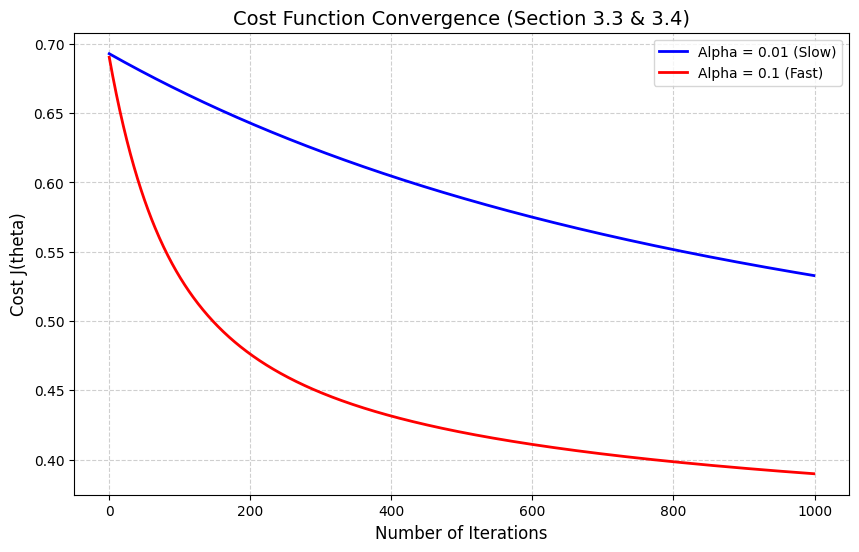

In [ ]:
#plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# alpha (0.01) history plot
plt.plot(costHistory1, label='Alpha = 0.01 (Slow)', color='blue', linewidth=2)

# alpha (0.1) history plot
plt.plot(costHistory2, label='Alpha = 0.1 (Fast)', color='red', linewidth=2)

# Graph enhancement
plt.title('Cost Function Convergence (Section 3.3 & 3.4)', fontsize=14)
plt.xlabel('Number of Iterations', fontsize=12)
plt.ylabel('Cost J(theta)', fontsize=12)
plt.legend() #
plt.grid(True, linestyle='--', alpha=0.6)

# Graph show
plt.show()

In [ ]:
#part 3.5
#Probabilities calculate(on test set)
probabilities = calculateSigmoid(np.dot(X_test, theta2))
#Threshold apply (0.5)
# if prob >= 0.5 then 1, else 0
predictions = (probabilities >= 0.5).astype(int)

# Y_test flattening
y_actual = y_test.flatten()
y_pred = predictions.flatten()

TP = np.sum((y_actual == 1) & (y_pred == 1))
TN = np.sum((y_actual == 0) & (y_pred == 0))
FP = np.sum((y_actual == 0) & (y_pred == 1))
FN = np.sum((y_actual == 1) & (y_pred == 0))

# Accuracy Formula
total = len(y_actual)
accuracy = (TP + TN) / total
cmMatrix = np.array([[TN, FP], [FN, TP]]) #cm matrix

# 2x2 Table Print
print("Confusion Matrix")
cm_df = pd.DataFrame(cmMatrix,index=["Actual 0", "Actual 1"],columns=["Pred 0", "Pred 1"])
print(cm_df)

Confusion Matrix
          Pred 0  Pred 1
Actual 0      49      10
Actual 1      11      39


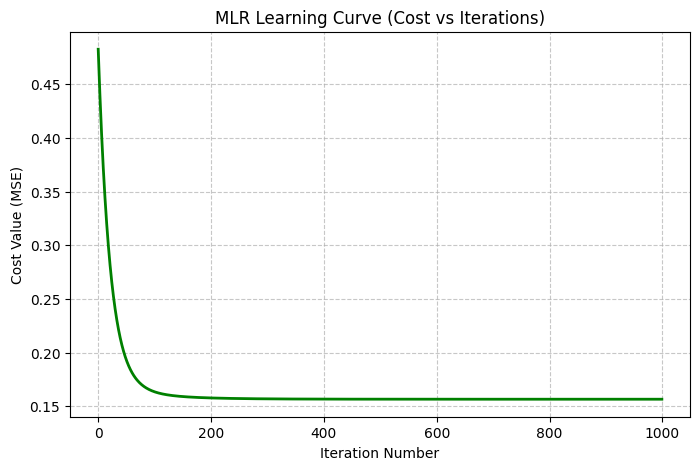

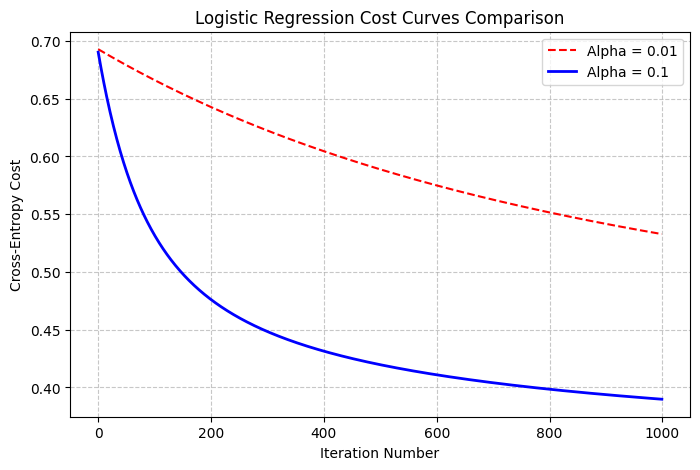

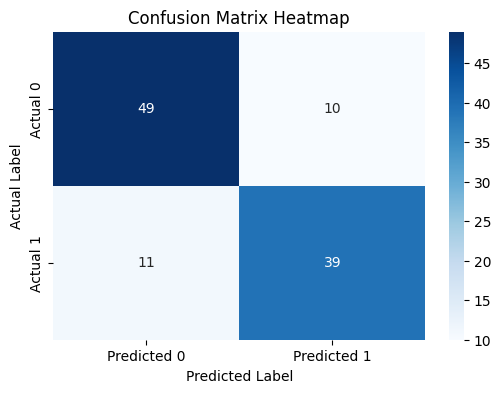

In [ ]:
#part 4
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
#4.1
plt.figure(figsize=(8, 5))
# using JHistoryLinear which has cost for each iteration
plt.plot(JHistoryLinear, color='green', linewidth=2)
plt.title("MLR Learning Curve (Cost vs Iterations)")
plt.xlabel("Iteration Number")
plt.ylabel("Cost Value (MSE)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
#My analysis: The cost has decreased sharply in the beginning and then steady or i guess constant throughout as iterations are incresng, which show that gradient descent is working fine, and model has converged

#4.2
plt.figure(figsize=(8, 5))
# using JHistory1
plt.plot(costHistory1, color='red', label='Alpha = 0.01', linestyle='--')
plt.plot(costHistory2, color='blue', label='Alpha = 0.1', linewidth=2)

plt.title("Logistic Regression Cost Curves Comparison")
plt.xlabel("Iteration Number")
plt.ylabel("Cross-Entropy Cost")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
#My analysis: by using both alphas, cost is descreasing but alpha = 0.1 is making the cost descrease significantly than alpha = 0.01, making the model to converge faster so alpha 0.1 is better

#4.3
#matrix calculate
# cm = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(6, 4))
sns.heatmap(cmMatrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()
#my analysis: the model has given 49+39 correct predictions which are 88 and 10+11 wrong answers which are 21
#my model has predicted class0 better than class 1, as 49 true predictions for class 0 while 39 true for class 1
#altho it has missclassify some as well but 80% it has given correct answers